In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data and convert Date column
df = pd.read_csv('../data/raw/SP500.csv', parse_dates=['Date'])

# 2. Fix the 'str' error: Force Adj Close to be numbers and drop missing values
df['Adj Close'] = pd.to_numeric(df['Adj Close'], errors='coerce')
df = df.dropna(subset=['Adj Close'])
df = df.sort_values('Date')

print("Data loaded and cleaned. Rows remaining:", len(df))

Data loaded and cleaned. Rows remaining: 24168


In [3]:
# 3. Calculate the running maximum price (the Peak)
df['peak'] = df['Adj Close'].cummax()

# 4. Calculate the drawdown percentage
# (Current Price - Peak) / Peak
df['drawdown'] = (df['Adj Close'] - df['peak']) / df['peak']

# 5. Find the Maximum Drawdown (MDD)
max_drawdown = df['drawdown'].min()
print(f"The Maximum Drawdown in this period was: {max_drawdown:.2%}")

The Maximum Drawdown in this period was: -83.02%


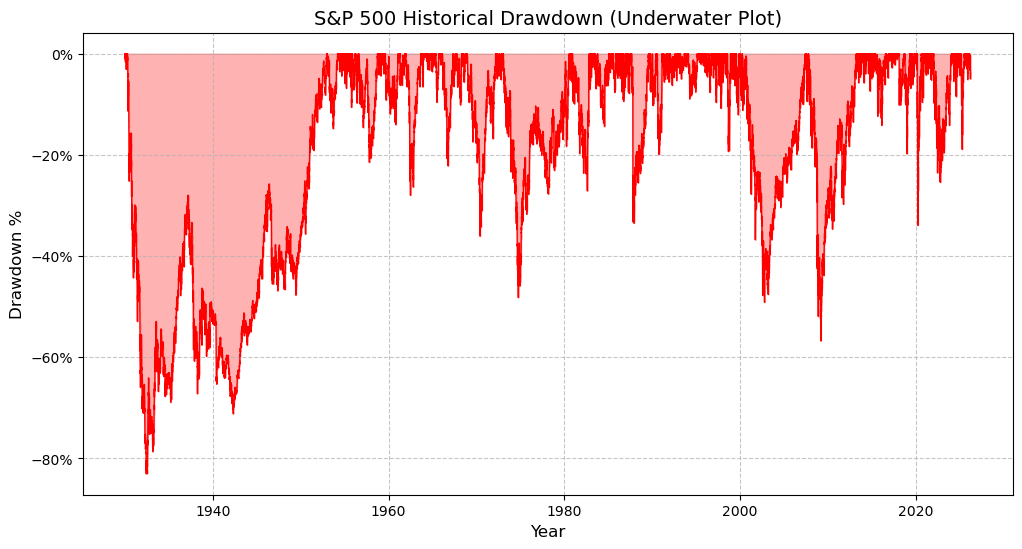

In [4]:
plt.figure(figsize=(12, 6))

# Fill the area to make it look professional
plt.fill_between(df['Date'], df['drawdown'], color='red', alpha=0.3)
plt.plot(df['Date'], df['drawdown'], color='red', linewidth=1)

# Formatting
plt.title('S&P 500 Historical Drawdown (Underwater Plot)', fontsize=14)
plt.ylabel('Drawdown %', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Format y-axis as percentage
import matplotlib.ticker as mtick
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.show()